In [1]:
from sklearn.feature_extraction import DictVectorizer
!wget https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv

--2026-09-16 09:47:12--  https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv
Loaded CA certificate '/etc/ssl/certs/ca-certificates.crt'
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 416 Range Not Satisfiable

    The file is already fully retrieved; nothing to do.



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('course_lead_scoring.csv')

In [4]:
df.industry.mode()

0    retail
Name: industry, dtype: str

In [5]:
df.isnull().sum()

lead_source                 128
industry                    134
number_of_courses_viewed      0
annual_income               181
employment_status           100
location                     63
interaction_count             0
lead_score                    0
converted                     0
dtype: int64

In [6]:
df.dtypes

lead_source                     str
industry                        str
number_of_courses_viewed      int64
annual_income               float64
employment_status               str
location                        str
interaction_count             int64
lead_score                  float64
converted                     int64
dtype: object

In [7]:
cat = ['lead_source', 'industry', 'employment_status','location']
num = ['number_of_courses_viewed','annual_income','interaction_count','lead_score','converted']

In [8]:
for c in cat:
    df[c] = df[c].fillna('NA')
for n in num:
    df[n] = df[n].fillna(0)

In [9]:
df.isnull().sum()

lead_source                 0
industry                    0
number_of_courses_viewed    0
annual_income               0
employment_status           0
location                    0
interaction_count           0
lead_score                  0
converted                   0
dtype: int64

In [10]:
df.industry.value_counts()

industry
retail           203
finance          200
other            198
healthcare       187
education        187
technology       179
manufacturing    174
NA               134
Name: count, dtype: int64

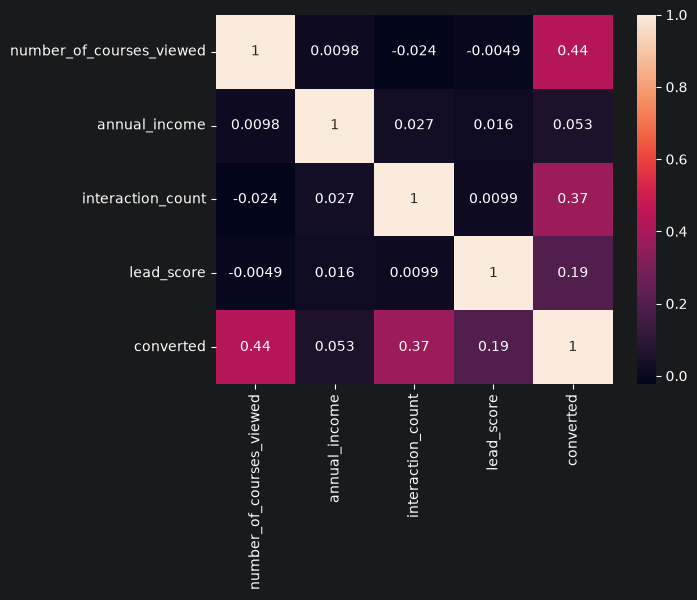

In [11]:
corr = df[num].corr()

sns.heatmap(corr, annot=True)
plt.show()

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
df_train_full, df_test = train_test_split(df, test_size = 0.2, random_state = 42)
df_train, df_val = train_test_split(df_train_full, test_size = 0.25, random_state = 42)

df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)

In [14]:
y_train = df_train['converted']
y_val = df_val['converted']
y_test = df_test['converted']

del df_train['converted']
del df_val['converted']
del df_test['converted']

In [15]:
from sklearn.metrics import mutual_info_score

In [16]:
def mutual_info_coverted_score(series):
    return round(mutual_info_score(series,df_train_full.converted), 2)

In [17]:
mi = df_train_full[cat].apply(mutual_info_coverted_score)
mi.sort_values(ascending=False)

lead_source          0.03
industry             0.01
employment_status    0.01
location             0.00
dtype: float64

In [18]:
cat = ['lead_source', 'industry', 'employment_status','location']
num = ['number_of_courses_viewed','annual_income','interaction_count','lead_score']

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [20]:
X_train_num = df_train[num].values
scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train_num)


In [21]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_train_cat = ohe.fit_transform(df_train[cat].values)

In [22]:
X_train = np.column_stack([X_train_num, X_train_cat])

In [23]:
model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The 

In [24]:
X_val_num = scaler.transform(df_val[num].values)
X_val_cat = ohe.transform(df_val[cat].values)
X_val = np.column_stack([X_val_num, X_val_cat])

In [25]:
y_pred = model.predict(X_val)

In [26]:
from sklearn.metrics import accuracy_score

In [27]:
round(accuracy_score(y_val, y_pred),2)

0.85

In [28]:
model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)
model.fit(X_train, y_train)
baseline = accuracy_score(y_val, model.predict(X_val))

In [29]:
baseline

0.8532423208191127

In [30]:
def accuracy_without(exclude):
    cat_f = [c for c in cat if c != exclude]
    num_f = [n for n in num if n != exclude]

    scaler_ = StandardScaler()
    X_tr_num = scaler_.fit_transform(df_train[num_f].values) if num_f else np.empty((len(df_train), 0))
    X_va_num = scaler_.transform(df_val[num_f].values) if num_f else np.empty((len(df_val), 0))

    ohe_ = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    X_tr_cat = ohe_.fit_transform(df_train[cat_f].values) if cat_f else np.empty((len(df_train), 0))
    X_va_cat = ohe_.transform(df_val[cat_f].values) if cat_f else np.empty((len(df_val), 0))

    X_tr = np.column_stack([X_tr_num, X_tr_cat])
    X_va = np.column_stack([X_va_num, X_va_cat])

    m = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)
    m.fit(X_tr, y_train)
    return accuracy_score(y_val, m.predict(X_va))

In [31]:
features = cat + num
diff = {}
for feature in features:
    acc = accuracy_without(feature)
    diff[feature] = baseline - acc

for f, d in sorted(diff.items(), key=lambda x: x[1]):
    print(f"{f:28s} acc_without={baseline-d:.4f} diff={d:.4f}")

least_useful = min(diff, key=diff.get)
print(f"\nLeast useful features: {least_useful}")

annual_income                acc_without=0.8532 diff=0.0000
lead_source                  acc_without=0.8498 diff=0.0034
location                     acc_without=0.8498 diff=0.0034
industry                     acc_without=0.8464 diff=0.0068
employment_status            acc_without=0.8362 diff=0.0171
lead_score                   acc_without=0.8191 diff=0.0341
interaction_count            acc_without=0.7713 diff=0.0819
number_of_courses_viewed     acc_without=0.7372 diff=0.1160

Least useful features: annual_income


In [33]:
for C in [0.000001,0.00001,0.0001,0.001]:
    model = LogisticRegression(solver='liblinear', C=C, max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    print(f"C={C}, acc = {round(accuracy_score(y_val, y_pred),3)}")

C=1e-06, acc = 0.785
C=1e-05, acc = 0.785
C=0.0001, acc = 0.788
C=0.001, acc = 0.812
